# Quantization and Normalization

In this notebook I will explore the mechanics behind quantization

In [1]:
import os
import sys
import pandas as pd
import json
from IPython.display import display, JSON
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import h5py
from copy import copy

sys.path.append("..")
sys.path.append("../code")

import torch

from dataset import PointCloudEmbeddingSequenceDataset

#### Adding Attributes (obj.name = "Said")
- In Python, instances have an internal dictionary (```__dict__```) that stores attributes.
- When you do ```obj.name = "Said"```, Python internally adds an entry to ```obj.__dict__``` like this:
```obj.__dict__["name"] = "Said"```
- When you access ```obj.name```, Python checks obj.__dict__ and returns "Said".

In [2]:
class Saver():
    pass

def construct_json_path(cad_seq_path):
    json_path = cad_seq_path.replace("cad_vec", "cad_json").replace("h5", "json")
    return json_path

def show_json():
    json_path = save.json_path
    print(json_path)
    with open(json_path, "r") as file:
        data = json.load(file)
    display(JSON(data))
    return data

def show_sample(idx, dataset):
    data = dataset[idx]
    pc, cad_seq, lat_rep, _ = data["pc"], data["tgt_vec"], data["z"], data["id"]
    pc_path = dataset.get_cad_seq_path(idx)
    
    seq_length = list(cad_seq[:, 0]).index(3) + 3
    commands = cad_seq[:seq_length, 0]
    arguments = cad_seq[:seq_length,1:]

    print("Commands:   ", commands.tolist())
    print("# of Loops: ", commands.tolist().count(4))
    command_list = torch.repeat_interleave(commands, 16).tolist()
    arg_list = []
    for command_args in arguments:
        arg_list += command_args.tolist()
                
    filtered_lists = [[x for x, trgt_arg in zip(lst, arg_list) if trgt_arg != -1] for lst in [command_list, arg_list]]
    command_list, arg_list = filtered_lists

    print("CAD-sequence path: ", pc_path)
    json_path = construct_json_path(pc_path)
    save.json_path = json_path
    print("Json path: ", json_path)
    df = pd.DataFrame(list(zip(command_list, arg_list)), columns=['command', 'argument'])
    return df

The json file contains three dicts:
- **entities**: Sketches and Extrusion
    - Sketch:
        - Transform object with origin and x-, y- and z-axis vectors.
        - Profile object with all curves it is made out of. Each curve can be Arc, Circle or Line and the respective args are listed.
    - Extrusion:
         - References the Sketch under profiles and the extrusion arguments extent one, extent two, operation and extent type
- **properties**: Bounding box
    - Contains maximum and minimum point
- **sequence**: Describes the sequence of sketch and extrude operations by referencing the entities

The pipeline from json to vector representation comprises the normalization and quantization. Lets look at this now.

1. ```json2vec.py```: Loads the json files and creates a ```CADSequence``` object per json file
    - ```CADSequence``` has a staticmethod to create the class from a dict which is the json file. All ```from_dict()``` methods will be implemented as ```get_()``` methods here, but the class definition will stay the same.
    - ```CADSequence``` searches for the all the Extrude operations in the sequence, creates an ```Extrude``` object for each, and concatenates them in a list.
2. 

In [3]:
from models.DeepCAD.cadlib.extrude import CADSequence, Extrude, CoordSystem
from models.DeepCAD.cadlib.sketch import Profile, Loop
from models.DeepCAD.cadlib.curves import Line, Arc, Circle

In [4]:
def get_CADSequence(all_stat):
    seq = []
    print("First we iterate thorough the sequence dict of the json and for each 'Extude_Feature' we create an 'Extrude' object.\n")
    for item in json_data["sequence"]:
        print(item)
        if item["type"] == "ExtrudeFeature":
            extrude_ops = get_Extrude(all_stat, item["entity"])
            seq.extend(extrude_ops)
    bbox_info = all_stat["properties"]["bounding_box"]
    max_point = np.array([bbox_info["max_point"]["x"], bbox_info["max_point"]["y"], bbox_info["max_point"]["z"]])
    min_point = np.array([bbox_info["min_point"]["x"], bbox_info["min_point"]["y"], bbox_info["min_point"]["z"]])
    bbox = np.stack([max_point, min_point], axis=0)
    print(f"After completing all extrusions, the bounding box dimensions are extracted again for the whole model "
          f"(not only for one extrusion: \n{bbox}")
    return CADSequence(seq, bbox)

In [5]:
def transform(translate, scale, sket_profile):
    for loop in sket_profile.children:
        for curve in loop.children:
            curve.transform(translate, scale)
    return sket_profile

In [6]:
def get_CoordSystem(stat):

    origin = np.array([stat["origin"]["x"], stat["origin"]["y"], stat["origin"]["z"]])
    normal_3d = np.array([stat["z_axis"]["x"], stat["z_axis"]["y"], stat["z_axis"]["z"]])
    x_axis_3d = np.array([stat["x_axis"]["x"], stat["x_axis"]["y"], stat["x_axis"]["z"]])
    y_axis_3d = np.array([stat["y_axis"]["x"], stat["y_axis"]["y"], stat["y_axis"]["z"]])
    print(f"\nThis is the original CoordSystem:\n"
          f"origin: {origin}\n"
          f"x     : {x_axis_3d}\n"
          f"y     : {y_axis_3d}\n"
          f"normal: {normal_3d}\n")
    plot_coordinate_system(origin, x_axis_3d, y_axis_3d, normal_3d)
    theta, phi, gamma = polar_parameterization(normal_3d, x_axis_3d)
    return CoordSystem(origin, theta, phi, gamma, y_axis=cartesian2polar(y_axis_3d))

In [7]:
%matplotlib inline
def plot_coordinate_system(origin, x_axis, y_axis, z_axis):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.quiver(*origin, *x_axis, color='r', label="X-axis")
    ax.quiver(*origin, *y_axis, color='g', label="Y-axis")
    ax.quiver(*origin, *z_axis, color='b', label="Z-axis")

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    ax.set_title("3D Coordinate System")

    max_range = np.max(np.abs([*origin, *x_axis, *y_axis, *z_axis])) + 0.5
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])
    ax.set_zlim([-max_range, max_range])

    plt.show()

In [8]:
def polar_parameterization(normal_3d, x_axis_3d):
    """represent a coordinate system by its rotation from the standard 3D coordinate system

    Args:
        normal_3d (np.array): unit vector for normal direction (z-axis)
        x_axis_3d (np.array): unit vector for x-axis

    Returns:
        theta, phi, gamma: axis-angle rotation 
    """
    normal_polar = cartesian2polar(normal_3d)
    theta = normal_polar[0]
    phi = normal_polar[1]
    print(f"\nTo create the CoordSystem we take the normal {normal_3d} of the sketch plane and convert it from cartesian to polar coordinates. "
          f"Thereby we obtain theta {(theta * 360)/(2*np.pi)} and phi {(phi * 360)/(2*np.pi)}.")

    print(f"\nNow lets exactly look what happens next. A standard x-axis [1,0,0] is first rotated by theta around the y-axis:\n")
    plot_coordinate_system(np.array([0,0,0]), np.array([1,0,0]), np.array([0,1,0]), np.array([0,0,1]))
    print(f"Rotation by theta = {theta} = {(theta * 360)/(2*np.pi) }: ")
    plot_coordinate_system(np.array([0,0,0]), rotate_by_y(np.array([1, 0, 0]), theta), np.array([0,1,0]), np.array([0,0,1]))
    print(f"\nThen the rotated x axis is rotated by phi = {(phi * 360)/(2*np.pi)} around the z-axis:\n")
    plot_coordinate_system(np.array([0,0,0]), rotate_by_z(rotate_by_y(np.array([1, 0, 0]), theta), phi), np.array([0,1,0]), np.array([0,0,1]))

    ref_x = rotate_by_z(rotate_by_y(np.array([1, 0, 0]), theta), phi)

    gamma = np.arccos(np.dot(x_axis_3d, ref_x).round(6))
    print(f"Then we calculate the angle between the rotated x axis and the x axis of the coordinate system using the dot product: "
         f"gamma = {(gamma * 360)/(2*np.pi)}")
    print(f"The reason why we calculated the angle between the reference x axis and the actual x axis of CoordSystem lies in the "
          f"definition of the Euler Angles. These three angles (phi, theta and gamma) describe a conversion from one coordinate "
          f"system to another only using angles. Theta and phi rotate the axis of coordinate system as usual, however for gamma "
          f"this is different. Gamma rotates an axis wrt the rotated x-axis. Therefore we need to know the angle between a reference "
          f"x axis and the actual x axis to obtain the gamma angle. Then we have the three euler angles describing a CS transformation. "
          f"This is why theta rotates around y and phi around z. Gamma rotates around x then. A 'CoordSystem' class comprises an origin, "
          f"the 3 Euler angles and a polar y-axis.")
    if np.dot(np.cross(ref_x, x_axis_3d), normal_3d) < 0:
        gamma = -gamma
    return theta, phi, gamma

In [9]:
def cartesian2polar(vec, with_radius=False):
    """convert a vector in cartesian coordinates to polar(spherical) coordinates"""
    vec = vec.round(6)
    norm = np.linalg.norm(vec)
    theta = np.arccos(vec[2] / norm) # (0, pi)
    phi = np.arctan(vec[1] / (vec[0] + 1e-15)) # (-pi, pi) # FIXME: -0.0 cannot be identified here
    if not with_radius:
        return np.array([theta, phi])
    else:
        return np.array([theta, phi, norm])


def polar2cartesian(vec):
    """convert a vector in polar(spherical) coordinates to cartesian coordinates"""
    r = 1 if len(vec) == 2 else vec[2]
    theta, phi = vec[0], vec[1]
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    return np.array([x, y, z])


def rotate_by_x(vec, theta):
    mat = np.array([[1, 0, 0],
                    [0, np.cos(theta), -np.sin(theta)],
                    [0, np.sin(theta), np.cos(theta)]])
    return np.dot(mat, vec)


def rotate_by_y(vec, theta):
    mat = np.array([[np.cos(theta), 0, np.sin(theta)],
                    [0, 1, 0],
                    [-np.sin(theta), 0, np.cos(theta)]])
    return np.dot(mat, vec)


def rotate_by_z(vec, phi):
    mat = np.array([[np.cos(phi), -np.sin(phi), 0],
                    [np.sin(phi), np.cos(phi), 0],
                    [0, 0, 1]])
    return np.dot(mat, vec)

In [10]:
def get_Profile(stat):
    print(f"A 'Profile' class is a list of 'Loop' classes, therefore to construct a 'Profile' we have to sequentially "
          f"create 'Loop' objects defined in the json data. Each sketch is made up of a 'Profile' for which we provided the id. "
          f"Under the profile id we can see the loops. Each 'Loop' has a 'is_outer' bool and a number of profile curves. These "
          f"will be provided to the 'Curve' constructor.\n")
    print(f"Number of loops in this Profile: {len(stat['loops'])}")
    all_loops = [get_Loop(item) for item in stat['loops']]
    print("\nFinally we created all Loops: ")
    for a in all_loops:
        print(a)
    all_loops = reorder_loops(all_loops)
    return Profile(all_loops, reorder=False) # in the original code reorder is set to True, here fore
    # documentation purposes the reorder method will be implemented outside of the class

In [11]:
def reorder_loops(children):
    if len(children) <= 1:
        print("\nIf the 'Profile' consists of only one Loop, no reordering is necessary") 
        return children

    print(f"\nTo order the Loops they are sorted according to their x_min bbox values, breaking ties using their y_min value. "
          f"Then the Loops are sorted starting with the Loops that has the lowest x_min and y_min values.")
    all_loops_bbox_min = np.stack([loop.bbox[0] for loop in children], axis=0).round(6)
    ind = np.lexsort(all_loops_bbox_min.transpose()[[1, 0]])
    children = [children[i] for i in ind]
    return children
    

In [12]:
def get_Loop(stat):
    print(f"\nThe 'Loop' class consists of a list of 'Curve' classes. The 'Loop' constructor iterates through the "
          f"curve information provided in the json data.")
    for i, item in enumerate(stat['profile_curves']):
        print(i, item)

    all_curves = [get_Curve(item) for item in stat['profile_curves']]
    all_curves = reorder_curves(all_curves)
    this_loop = Loop(all_curves, reorder=False)
    this_loop.to_image()
    # in the original code reorder is set to True, here fore
    # documentation purposes the reorder method will be implemented outside of the class
    this_loop.is_outer = stat['is_outer']
    return this_loop

In [13]:
def reorder_curves(children):
    """reorder by starting left most and counter-clockwise"""
    if len(children) <= 1:
        print("\nIf the 'Loop' consists of only one Curve, no reordering is necessary") 
        return children

    start_curve_idx = -1
    sx, sy = 10000, 10000

    # correct start-end point order
    print("\nREORDERING CURVES\nWhen reordering curves the goal is to have them starting left most and counter-clockwise.")
    print(f"\nIn reordering the curves, first we check for the first two curves if the start point "
              f"of the first and second Curve is the same ({np.allclose(children[0].start_point, children[1].start_point)}) "
              f"or if the start point of the first and the end point of the second Curve is the same "
              f"({np.allclose(children[0].start_point, children[1].end_point)}). If yes, then the first curve get reversed, i.e. "
              f"for 'Line' and 'Arc' the start and end point are switched.")
    if np.allclose(children[0].start_point, children[1].start_point) or \
        np.allclose(children[0].start_point, children[1].end_point):
        children[0].reverse()

    # correct start-end point order and find left-most point
    print("\nNow we iterate through the curves and everytime two consecutive curves have the same end point, reverse the second curve."
          " Then we find the left most point of all curves.")
    for i, curve in enumerate(children):
        if i < len(children) - 1 and np.allclose(curve.end_point, children[i + 1].end_point):
            children[i + 1].reverse()
        if round(curve.start_point[0], 6) < round(sx, 6) or \
                (round(curve.start_point[0], 6) == round(sx, 6) and round(curve.start_point[1], 6) < round(sy, 6)):
            start_curve_idx = i
            sx, sy = curve.start_point

    children = children[start_curve_idx:] + children[:start_curve_idx]

    # ensure mostly counter-clock wise
    if isinstance(children[0], Circle) or isinstance(children[-1], Circle): # FIXME: hard-coded
        return children
    start_vec = children[0].direction()
    end_vec = children[-1].direction(from_start=False)
    if np.cross(end_vec, start_vec) <= 0:
        for curve in children:
            curve.reverse()
        children.reverse()
    return children

In [14]:
def get_Curve(stat):
    print(f"\nDepending on the type of 'Curve' (Arc, Line, Circle) call the respective constructor.\n")
    print(f"Type: {stat['type']}")
    if stat['type'] == "Line3D":
        return get_Line(stat)
    elif stat['type'] == "Circle3D":
        return get_Circle(stat)
    elif stat['type'] == "Arc3D":
        return get_Arc(stat)
    else:
        raise NotImplementedError("curve type not supported yet: {}".format(stat['type']))

In [15]:
def get_Line(stat):
    assert stat['type'] == "Line3D"
    print(f"To create a 'Line' object, we extract the start and endpoint of the line as numpy arrays.")
    start_point = np.array([stat['start_point']['x'],
                            stat['start_point']['y']])
    end_point = np.array([stat['end_point']['x'],
                          stat['end_point']['y']])
    print(f"Start point: {start_point}\nEnd point: {end_point}")
    return Line(start_point, end_point)

def get_Circle(stat):
    print(f"To create a 'Circle' object, we extract the center point, the radius and the normal.")
    assert stat['type'] == "Circle3D"
    center = np.array([stat['center_point']['x'],
                       stat['center_point']['y']])
    radius = stat['radius']
    normal = np.array([stat['normal']['x'],
                       stat['normal']['y'],
                       stat['normal']['z']])
    print(f"Center: {center}, Radius: {radius}, Normal: {normal}")
    return Circle(center, radius, normal)

def get_Arc(stat):
    print(f"To create a 'Arc' object, we extract the start-, center- and end-point, the radius, the normal, "
          f"the start- and eng-angle and the reference vector.")
    assert stat['type'] == "Arc3D"
    start_point = np.array([stat['start_point']['x'],
                            stat['start_point']['y']])
    end_point = np.array([stat['end_point']['x'],
                          stat['end_point']['y']])
    center = np.array([stat['center_point']['x'],
                       stat['center_point']['y']])
    radius = stat['radius']
    normal = np.array([stat['normal']['x'],
                       stat['normal']['y'],
                       stat['normal']['z']])
    start_angle = stat['start_angle']
    end_angle = stat['end_angle']
    ref_vec = np.array([stat['reference_vector']['x'],
                        stat['reference_vector']['y']])
    print(f"Start point: {start_point}\nEnd point: {end_point}\nCenter: {center}\nRadius: {radius}\nNormal: {normal}\n"
          f"Start angle: {start_angle}\nEnd angle: {end_angle}\nReference vector: {ref_vec}")
    return Arc(start_point, end_point, center, radius, normal, start_angle, end_angle, ref_vec)

In [16]:
NORM_FACTOR = 0.75
def normalize(size, sket_profile, sket_size):
    cur_size = sket_size
    scale = (size / 2 * NORM_FACTOR - 1) / cur_size
    print(f"Scale: {scale}")
    print(f"The goal of normalization is to normalize within the given size with the start point in the middle center. "
          f"In normalization we want the maximum extent of the bounding box {sket_size} to be (256 / 2) * NORM_FACTOR - 1), i.e. "
          f"{(size / 2 * NORM_FACTOR - 1)}. The scale is then the factor by which the bbox size has to be multiplied with to "
          f"reach that target.")
    print("\nBOUNDING BOXES\n")
    print("Profile\n", sket_profile.bbox)
    print(f"To calculate the bounding box size {sket_profile.bbox_size}, i.e. the maximum extent, first the bbox min and max are extracted: ")
    print(f"bbox_min: {sket_profile.bbox[0]}, bbox_max: {sket_profile.bbox[1]}")
    print(f"Then the start point {sket_profile.start_point} is substracted from the min and max: ")
    temp1_max = sket_profile.bbox[1] - sket_profile.start_point
    temp2_min = sket_profile.bbox[0] - sket_profile.start_point
    print(f"bbox_min-start_point: {temp2_min}, bbox_max-start_point: {temp1_max}")
    temp3_concat = np.concatenate([temp1_max, temp2_min])
    print(f"The sript of the authors concatenates the two points: {temp3_concat}")
    print(f"Then they extract the maximum absolute value: {np.max(np.abs(temp3_concat))}")
    print("BUT THIS IS THE MAXIMUM DISTANCE OF THE BOUNDING BOX TO THE START POINT, NOT THE MAX BOUNDING BOX EXTENT --> ERROR?")
    for i, loop in enumerate(sket_profile.children):
        print("\nLoop ", i, "\n", loop.bbox)
        for curve in loop.children:
            print(curve)
            print(curve.bbox)
    print("The normalization is twofold:\nFirst all curves are translated by the negative starting point of the Profile, resulting "
          "in the starting point being at the origin and all parameters being scaled to be within 0 and 255.\nThen all curves in the "
          "Profile are translated again by 128 in x and y direction resulting in a 128 being the middle value, i.e. every value which"
          "was 0 before is now 128 and every value <0 is below 128 and vice versa.")
    print(f"\nThe Bounding Box Size describes the maximum extent of the bounding box.\n"
          f"Bounding Box size: {sket_profile.bbox_size}")
    print(f"\nLoops after translating the negative start point: {sket_profile.start_point}\n")
    sket_profile = transform(-sket_profile.start_point, 1, sket_profile) # translating
    sket_profile.to_image()
    for loop in sket_profile.children:
        print(loop)
    sket_profile = transform(np.array([0,0]), scale, sket_profile) # scaling
    sket_profile.to_image()
    print(f"\nLoops after scaling them by {scale}:\n")
    for loop in sket_profile.children:
        print(loop)
    print(f"Bounding Box size: {sket_profile.bbox_size}")
    sket_profile = transform((size/2, size/2), 1, sket_profile) # scaled translate
    sket_profile.to_image()
    print(f"\nLoops after translating them by half the size: {size/2}")
    for loop in sket_profile.children:
        print(loop)
    print(f"Bounding Box size: {sket_profile.bbox_size}")
    return sket_profile

In [17]:
EXTRUDE_OPERATIONS = ["NewBodyFeatureOperation", "JoinFeatureOperation",
                      "CutFeatureOperation", "IntersectFeatureOperation"]
EXTENT_TYPE = ["OneSideFeatureExtentType", "SymmetricFeatureExtentType",
               "TwoSidesFeatureExtentType"]

%matplotlib inline
def get_Extrude(all_stat, extrude_id, sketch_dim=256):
    
    extrude_entity = all_stat["entities"][extrude_id]
    assert extrude_entity["start_extent"]["type"] == "ProfilePlaneStartDefinition"
    all_skets = []
    n = len(extrude_entity["profiles"])

    print(f"\nTo create the 'Extrude' object for {extrude_id} we calculate the number of profiles it contains: {n}\n")

    for i in range(len(extrude_entity["profiles"])):
        sket_id, profile_id = extrude_entity["profiles"][i]["sketch"], extrude_entity["profiles"][i]["profile"]
        print(f"We then extract the sketch id of the profile: {sket_id}, and the profile id: {profile_id}\n")
        sket_entity = all_stat["entities"][sket_id]
        print(f"Then we create a 'Profile' class by providing the profile id {profile_id} to the Profile constructor.\n")
        
        sket_profile = get_Profile(sket_entity["profiles"][profile_id])
        sket_profile.to_image()
        print(f"\nAfter we created the profile we have to provide a 'CoordSystem' class as well. The information is stored in the "
              f"sket_entity {sket_id} under 'transform'.")
        sket_plane = get_CoordSystem(sket_entity["transform"])

        print(f"\nAfter obtaining the Profile and CoordSystem, the Profile is normalized.\n Therefore, the left most point of the "
              f"Profile is extracted as well as the maximum extent of the bbox.\n Then the Profile is normalized which will be "
              f"scrutinized now. Normalizing comprises for all curves: **Subtracting** the start point of the Profile to all "
              f"parameters and scaling them by the scale.")

        point = sket_profile.start_point
        print(f"Start Point: {point}")
        sket_pos = point[0] * sket_plane.x_axis + point[1] * sket_plane.y_axis + sket_plane.origin
        sket_size = sket_profile.bbox_size
        print("\nLoops before normalization: ")
        for loop in sket_profile.children:
            print(loop)
        sket_profile = normalize(sketch_dim, sket_profile, sket_size)
        all_skets.append((sket_profile, sket_plane, sket_pos, sket_size))
        print("\nNow the creation of the Extrude operation is done by appending it to a list in a tuple including the 'Profile"
             "'CoordSystem', the positon of the sketch (start point in the global coord system) and the maximum size of the sketch: ")
        for item in all_skets:
            for tuple_item in item:
                print(tuple_item)
        print(all_skets)

    operation = EXTRUDE_OPERATIONS.index(extrude_entity["operation"])
    print(f"\nWhat is left now is to extract the extrusion information. Therefore we extract the extrusion operation: "
          f"{extrude_entity['operation']} and the corresponding index {operation}.")
    extent_type = EXTENT_TYPE.index(extrude_entity["extent_type"])
    print(f"\nThe extent type is also extracted: "
          f"{extrude_entity['extent_type']} and the corresponding index {extent_type}.")
    extent_one = extrude_entity["extent_one"]["distance"]["value"]
    print(f"\nThe extent in the first direction is saved in the json file: {extent_one}. The second extent distance is only applied "
          f"if the extent type is 'TwoSidesFeatureExtentType'.")
    extent_two = 0.0
    if extrude_entity["extent_type"] == "TwoSidesFeatureExtentType":
        extent_two = extrude_entity["extent_two"]["distance"]["value"]
    if operation == EXTRUDE_OPERATIONS.index("NewBodyFeatureOperation"):
        all_operations = [operation] + [EXTRUDE_OPERATIONS.index("JoinFeatureOperation")] * (n - 1)
    else:
        all_operations = [operation] * n

    print(f"\n Then a list marking all extrude operations is created. If the extrusion creates the first object "
            f"then the first operation is a 'NewBodyFeatureOperation' and the rest a 'JoinFeatureOperation'. "
            f"If the first operation is a cut or intersection, then of course all profiles in that extrusion "
            f"perform that cut or intersection:\n{[EXTRUDE_OPERATIONS[i] for i in all_operations]}")
    print("\nFinally the Extrusion object is returned, comprising of the 'Profile', 'CoordSystem', operation, extent type with "
          "the extent distance in both diretion, the position of the sketch and the size of the sketch.")
    return [Extrude(all_skets[i][0], all_skets[i][1], all_operations[i], extent_type, extent_one, extent_two,
                    all_skets[i][2], all_skets[i][3]) for i in range(n)]

In [20]:
dataset = PointCloudEmbeddingSequenceDataset("../data", 'train')
print(f"Dataset contains {len(dataset)} samples.")
save = Saver()

Dataset contains 160982 samples.


In [37]:
idx = 12 #4561

Below is a target vectorized CAD-sequence. In the following cells I will scrutinize the transformation from json data to this format.

In [38]:
show_sample(idx, dataset)

Commands:    [4, 2, 5, 3, 3, 3]
# of Loops:  1
CAD-sequence path:  ../data/cad_vec/0022/00221760.h5
Json path:  ../data/cad_json/0022/00221760.json


,command,argument
0,2,176
1,2,128
2,2,47
3,5,192
4,5,128
5,5,192
6,5,128
7,5,127
8,5,128
9,5,3


In [39]:
json_data = show_json()

../data/cad_json/0022/00221760.json


<IPython.core.display.JSON object>

First we iterate thorough the sequence dict of the json and for each 'Extude_Feature' we create an 'Extrude' object.

{'index': 0, 'type': 'Sketch', 'entity': 'FIbHm0WVCqrz8E1_0'}
{'index': 1, 'type': 'ExtrudeFeature', 'entity': 'FoiwUJfoB1NiHuK_0'}

To create the 'Extrude' object for FoiwUJfoB1NiHuK_0 we calculate the number of profiles it contains: 1

We then extract the sketch id of the profile: FIbHm0WVCqrz8E1_0, and the profile id: JGC

Then we create a 'Profile' class by providing the profile id JGC to the Profile constructor.

A 'Profile' class is a list of 'Loop' classes, therefore to construct a 'Profile' we have to sequentially create 'Loop' objects defined in the json data. Each sketch is made up of a 'Profile' for which we provided the id. Under the profile id we can see the loops. Each 'Loop' has a 'is_outer' bool and a number of profile curves. These will be provided to the 'Curve' constructor.

Number of loops in this Profile: 1

The 'Loop' class consists of a list of 'C

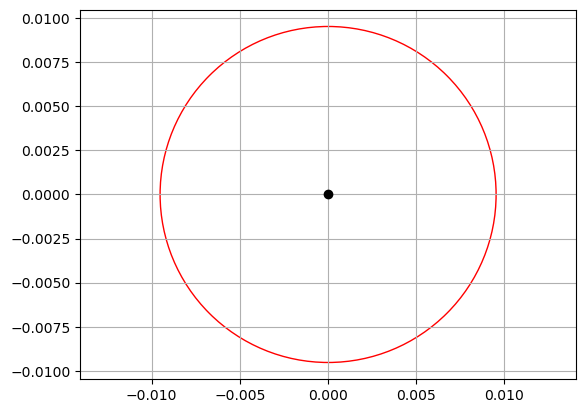


Finally we created all Loops: 
Loop:
      -Circle: center([0. 0.]), radius(0.009525)

If the 'Profile' consists of only one Loop, no reordering is necessary


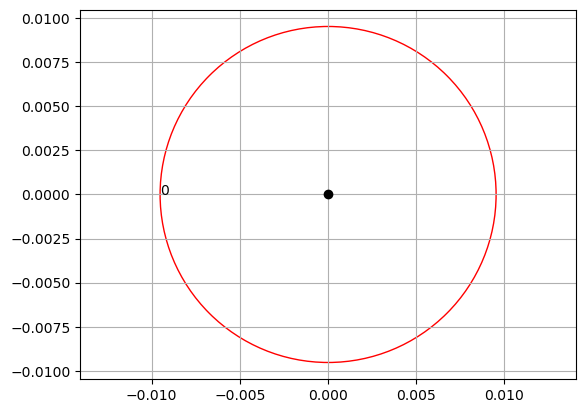


After we created the profile we have to provide a 'CoordSystem' class as well. The information is stored in the sket_entity FIbHm0WVCqrz8E1_0 under 'transform'.

This is the original CoordSystem:
origin: [0. 0. 0.]
x     : [0. 1. 0.]
y     : [0. 0. 1.]
normal: [1. 0. 0.]



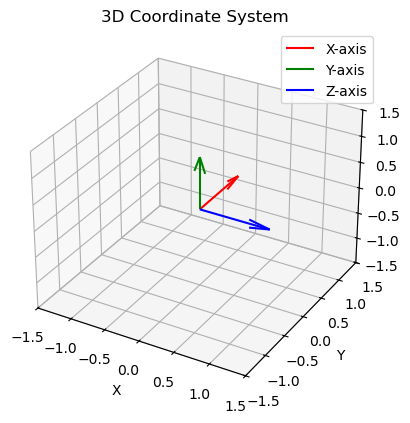


To create the CoordSystem we take the normal [1. 0. 0.] of the sketch plane and convert it from cartesian to polar coordinates. Thereby we obtain theta 90.0 and phi 0.0.

Now lets exactly look what happens next. A standard x-axis [1,0,0] is first rotated by theta around the y-axis:



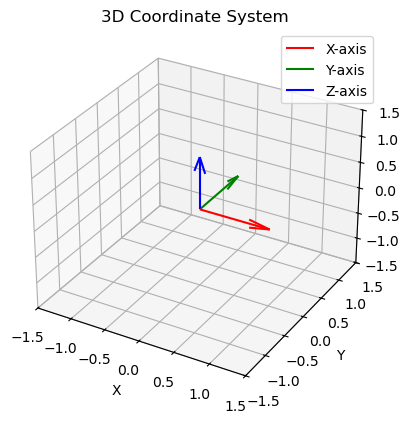

Rotation by theta = 1.5707963267948966 = 90.0: 


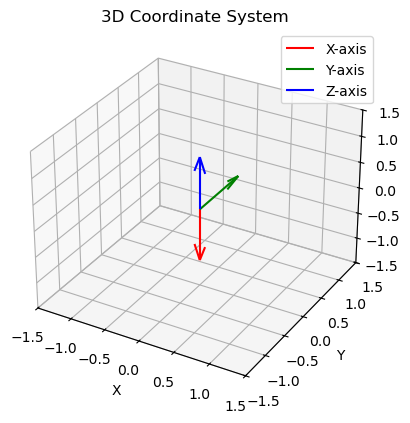


Then the rotated x axis is rotated by phi = 0.0 around the z-axis:



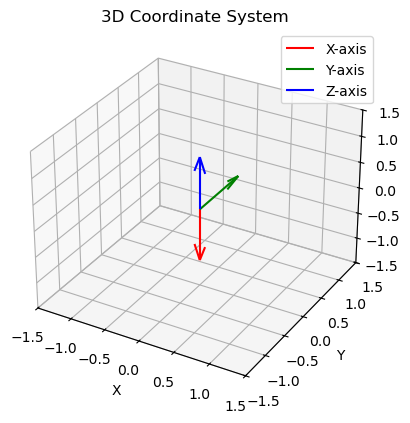

Then we calculate the angle between the rotated x axis and the x axis of the coordinate system using the dot product: gamma = 90.0
The reason why we calculated the angle between the reference x axis and the actual x axis of CoordSystem lies in the definition of the Euler Angles. These three angles (phi, theta and gamma) describe a conversion from one coordinate system to another only using angles. Theta and phi rotate the axis of coordinate system as usual, however for gamma this is different. Gamma rotates an axis wrt the rotated x-axis. Therefore we need to know the angle between a reference x axis and the actual x axis to obtain the gamma angle. Then we have the three euler angles describing a CS transformation. This is why theta rotates around y and phi around z. Gamma rotates around x then. A 'CoordSystem' class comprises an origin, the 3 Euler angles and a polar y-axis.

After obtaining the Profile and CoordSystem, the Profile is normalized.
 Therefore, the left most point of the

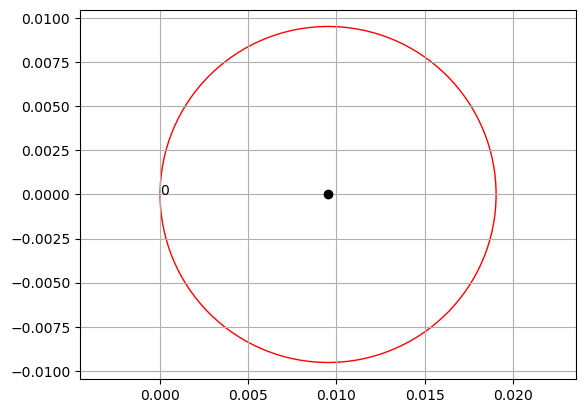

Loop:
      -Circle: center([0.009525 0.      ]), radius(0.009525)


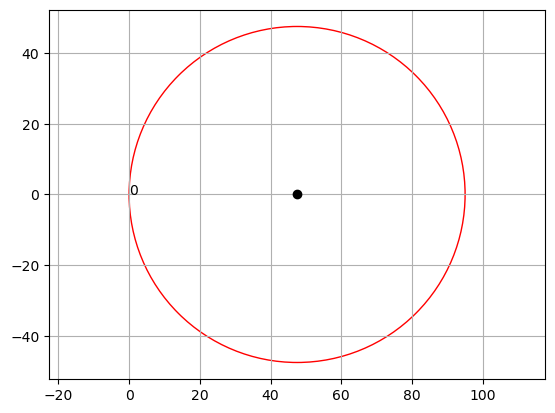


Loops after scaling them by 4986.876640419947:

Loop:
      -Circle: center([47.5  0. ]), radius(47.49999999999999)
Bounding Box size: 94.99999999999999


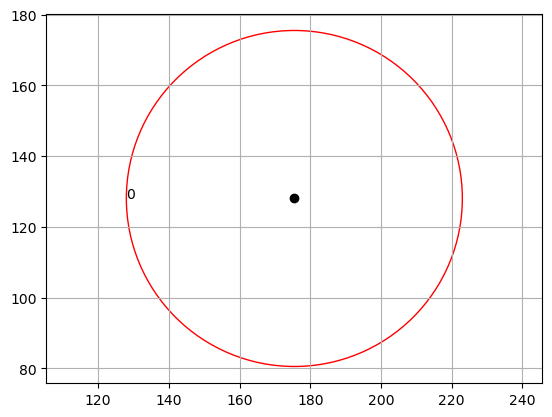


Loops after translating them by half the size: 128.0
Loop:
      -Circle: center([175.5 128. ]), radius(47.49999999999999)
Bounding Box size: 95.0

Now the creation of the Extrude operation is done by appending it to a list in a tuple including the 'Profile'CoordSystem', the positon of the sketch (start point in the global coord system) and the maximum size of the sketch: 
Profile:Loop:
      -Circle: center([175.5 128. ]), radius(47.49999999999999)
origin: [0. 0. 0.], normal: [1. 0. 0.], x_axis: [ 0.  1. -0.], y_axis: [0. 0. 1.]
[-3.57130298e-35 -9.52500000e-03  5.83238038e-19]
0.01905
[(<models.DeepCAD.cadlib.sketch.Profile object at 0x16b8aaa00>, <models.DeepCAD.cadlib.extrude.CoordSystem object at 0x16b00ce20>, array([-3.57130298e-35, -9.52500000e-03,  5.83238038e-19]), 0.01905)]

What is left now is to extract the extrusion information. Therefore we extract the extrusion operation: NewBodyFeatureOperation and the corresponding index 0.

The extent type is also extracted: OneSideF

In [40]:
CAD_Sequence = get_CADSequence(json_data)
print(CAD_Sequence)

After that the CAD_Sequence is normaluzed

## CAD_Sequence complete

At this point we completed the generation of the CAD-Sequence. However it still remains to normalize, numericalize and vectorize the CAD-Sequence, which will be scrutinized now. First lets attend to normlizing the CAD-sequence

### Normalizing

In [83]:
def normalize_CAD_Sequence(cad_sequence, size=1.0):
    print(f"CAD-sequence Bounding Box: \n{cad_sequence.bbox}")
    print("To normalize the CAD-sequence, the transform method already discussed before is used only providing a scale and no "
      f"translation. The only difference to the transform method of 'Profile' is, that the transform method of the CAD-sequence "
      f"class does not affect the curves, but only the extrude parameters like extent one and so on. "
      f"The scale is again calculated using a norm factor of {NORM_FACTOR} and the maximum extend of the bounding "
      f"box of the CAD-Sequence: {np.max(np.abs(cad_sequence.bbox))}.")
    print("ERROR: AGAIN THEY DONT CALCULATE THE BBOX EXTENT CORRECTLY!")
    scale = size * NORM_FACTOR / np.max(np.abs(cad_sequence.bbox))
    print(f"The scale equates to {scale}.")

    print("The CAD-sequence before transforming: ")
    for extrusion in cad_sequence.seq:
        print(extrusion)

    cad_sequence.transform(0.0, scale)
    print("The CAD-sequence after transforming: ")
    for extrusion in cad_sequence.seq:
        print(extrusion)
    return cad_sequence

In [84]:
norm_cad_sequence = normalize_CAD_Sequence(CAD_Sequence)

CAD-sequence Bounding Box: 
[[ 0.01   0.     0.025]
 [-0.01  -0.003 -0.025]]
To normalize the CAD-sequence, the transform method already discussed before is used only providing a scale and no translation. The only difference to the transform method of 'Profile' is, that the transform method of the CAD-sequence class does not affect the curves, but only the extrude parameters like extent one and so on. The scale is again calculated using a norm factor of 0.75 and the maximum extend of the bounding box of the CAD-Sequence: 0.025.
ERROR: AGAIN THEY DONT CALCULATE THE BBOX EXTENT CORRECTLY!
The scale equates to 30.0.
The CAD-sequence before transforming: 
Sketch-Extrude pair:
  -origin: [0. 0. 0.], normal: [ 0. -1.  0.], x_axis: [ 1.  0. -0.], y_axis: [0. 0. 1.]
  -sketch position: [-0.01  -0.    -0.015], sketch size: 0.04
  -operation:0, type:0, extent_one:0.003, extent_two:0.0
  -Profile:Loop:
      -Arc: start([128. 128.]), end([175.5 128. ]), mid([151.75 104.25])
      -Line: start([17

After normalizing the next step is to numericalize the CAD-Sequence
### Numericalize

In [85]:
def numericalize_cad_sequence(cad_sequence):
    new_seq = []
    for extrusion in cad_sequence.seq:
        numericalize_extrusion(extrusion)
    return cad_sequence

In [86]:
def numericalize_extrusion(extrusion, n=256):
    print("Before numericalization: \n")
    print(extrusion, "\n")
    print(f"Sketch plane angles: phi {extrusion.sketch_plane._phi} gamma {extrusion.sketch_plane._gamma} theta {extrusion.sketch_plane._theta}")
    numericalize_profile(extrusion.profile)
    numericalize_sketch_plane(extrusion.sketch_plane)

    print("After the Profile and CoordSystem were numericalized, it is only left to numericalize the extrusion parameters"
         "extent_one, extent_two, operation, extent_type, sketch_pos and sketch_size")

    extrusion.extent_one = ((extrusion.extent_one + 1.0) / 2 * n).round().clip(min=0, max=n-1).astype(np.int32) 
    extrusion.extent_two = ((extrusion.extent_two + 1.0) / 2 * n).round().clip(min=0, max=n-1).astype(np.int32) 
    
    extrusion.operation = int(extrusion.operation)
    extrusion.extent_type = int(extrusion.extent_type)

    extrusion.sketch_pos = ((extrusion.sketch_pos + 1.0) / 2 * n).round().clip(min=0, max=n-1).astype(np.int32) 
    extrusion.sketch_size = (extrusion.sketch_size / 2 * n).round().clip(min=0, max=n-1).astype(np.int32) 

    
    print("After numericalization: \n", extrusion, "\n")
    print(f"Sketch plane angles: phi {extrusion.sketch_plane._phi} gamma {extrusion.sketch_plane._gamma} theta {extrusion.sketch_plane._theta}")

In [87]:
def numericalize_profile(profile, n=256):
    for loop in profile.children:
        numericalize_loop(loop, n=n)

In [88]:
def numericalize_loop(loop, n=256):
   # print(loop, "\n")
    for curve in loop.children:
        numericalize_curve(curve, n=n)

In [89]:
def numericalize_curve(curve, n=256):
    if isinstance(curve, Line):
        numericalize_line(curve, n=n)
    if isinstance(curve, Circle):
        numericalize_circle(curve, n=n)
    if isinstance(curve, Arc):
        numericalize_arc(curve, n=n)
    

In [90]:
def numericalize_line(line, n=256):
   # print(line, "\n")
    line.start_point = line.start_point.round().clip(min=0, max=n-1).astype(np.int64)
    line.end_point = line.end_point.round().clip(min=0, max=n-1).astype(np.int64)


def numericalize_circle(circle, n=256):
  #  print(circle, "\n")
    circle.center = circle.center.round().clip(min=0, max=n-1).astype(np.int64)
    circle.radius = np.round(circle.radius).clip(min=1, max=n-1).astype(np.int64)
    
def numericalize_arc(arc, n=256):
   # print(arc, "\n")
    arc.start_point = arc.start_point.round().clip(min=0, max=n-1).astype(np.int64)
    arc.mid_point = arc.mid_point.round().clip(min=0, max=n-1).astype(np.int64)
    arc.end_point = arc.end_point.round().clip(min=0, max=n-1).astype(np.int64)
    arc.center = arc.center.round().clip(min=0, max=n-1).astype(np.int64)
    tmp = np.array([arc.start_angle, arc.end_angle])
    arc.start_angle, arc.end_angle = (tmp / (2 * np.pi) * n).round().clip(
                                        min=0, max=n-1).astype(np.int64)

In [91]:
def numericalize_sketch_plane(sketch_plane, n=256):
    sketch_plane.origin = ((sketch_plane.origin + 1.0) / 2 * n).round().clip(min=0, max=n-1).astype(np.int64)
    tmp = np.array([sketch_plane._theta, sketch_plane._phi, sketch_plane._gamma])
    sketch_plane._theta, sketch_plane._phi, sketch_plane._gamma = ((tmp / np.pi + 1.0) / 2 * n).round().clip(
        min=0, max=n-1).astype(np.int64)
    sketch_plane.is_numerical = True

def denumericalize_sketch_plane(sketch_plane, n=256):
    sketch_plane.origin = sketch_plane.origin / n * 2 - 1.0
    tmp = np.array([sketch_plane._theta, sketch_plane._phi, sketch_plane._gamma])
    sketch_plane._theta, sketch_plane._phi, sketch_plane._gamma = (tmp / n * 2 - 1.0) * np.pi
    sketch_plane.is_numerical = False

In [92]:
cad_seq_norm_num = numericalize_cad_sequence(norm_cad_sequence)

Before numericalization: 

Sketch-Extrude pair:
  -origin: [0. 0. 0.], normal: [ 0. -1.  0.], x_axis: [ 1.  0. -0.], y_axis: [0. 0. 1.]
  -sketch position: [-0.3  -0.   -0.45], sketch size: 1.2
  -operation:0, type:0, extent_one:0.09, extent_two:0.0
  -Profile:Loop:
      -Arc: start([128. 128.]), end([175.5 128. ]), mid([151.75 104.25])
      -Line: start([175.5 128. ]), end([175.5  199.25])
      -Arc: start([175.5  199.25]), end([128.   199.25]), mid([151.75 223.  ])
      -Line: start([128.   199.25]), end([128. 128.])
    -Loop:
      -Circle: center([151.75 128.  ]), radius(4.75)
    -Loop:
      -Circle: center([151.75 199.25]), radius(4.75) 

Sketch plane angles: phi -1.5707963267948957 gamma 1.5707963267948966 theta 1.5707963267948966
After the Profile and CoordSystem were numericalized, it is only left to numericalize the extrusion parametersextent_one, extent_two, operation, extent_type, sketch_pos and sketch_size
After numericalization: 
 Sketch-Extrude pair:
  -origin: [12

## TO Vector

Here all the previous created elements are aggregated into the final vector representation. As this is only the rearranging of attributes, it will not be scrutinized in detail.

In [93]:
import numpy as np

ALL_COMMANDS = ['Line', 'Arc', 'Circle', 'EOS', 'SOL', 'Ext']
LINE_IDX = ALL_COMMANDS.index('Line')
ARC_IDX = ALL_COMMANDS.index('Arc')
CIRCLE_IDX = ALL_COMMANDS.index('Circle')
EOS_IDX = ALL_COMMANDS.index('EOS')
SOL_IDX = ALL_COMMANDS.index('SOL')
EXT_IDX = ALL_COMMANDS.index('Ext')

EXTRUDE_OPERATIONS = ["NewBodyFeatureOperation", "JoinFeatureOperation",
                      "CutFeatureOperation", "IntersectFeatureOperation"]
EXTENT_TYPE = ["OneSideFeatureExtentType", "SymmetricFeatureExtentType",
               "TwoSidesFeatureExtentType"]

PAD_VAL = -1
N_ARGS_SKETCH = 5 # sketch parameters: x, y, alpha, f, r
N_ARGS_PLANE = 3 # sketch plane orientation: theta, phi, gamma
N_ARGS_TRANS = 4 # sketch plane origin + sketch bbox size: p_x, p_y, p_z, s
N_ARGS_EXT_PARAM = 4 # extrusion parameters: e1, e2, b, u
N_ARGS_EXT = N_ARGS_PLANE + N_ARGS_TRANS + N_ARGS_EXT_PARAM
N_ARGS = N_ARGS_SKETCH + N_ARGS_EXT

SOL_VEC = np.array([SOL_IDX, *([PAD_VAL] * N_ARGS)])
EOS_VEC = np.array([EOS_IDX, *([PAD_VAL] * N_ARGS)])

CMD_ARGS_MASK = np.array([[1, 1, 0, 0, 0, *[0]*N_ARGS_EXT],  # line
                          [1, 1, 1, 1, 0, *[0]*N_ARGS_EXT],  # arc
                          [1, 1, 0, 0, 1, *[0]*N_ARGS_EXT],  # circle
                          [0, 0, 0, 0, 0, *[0]*N_ARGS_EXT],  # EOS
                          [0, 0, 0, 0, 0, *[0]*N_ARGS_EXT],  # SOL
                          [*[0]*N_ARGS_SKETCH, *[1]*N_ARGS_EXT]]) # Extrude

NORM_FACTOR = 0.75 # scale factor for normalization to prevent overflow during augmentation

MAX_N_EXT = 10 # maximum number of extrusion
MAX_N_LOOPS = 6 # maximum number of loops per sketch
MAX_N_CURVES = 15 # maximum number of curves per loop
MAX_TOTAL_LEN = 60 # maximum cad sequence length
ARGS_DIM = 256


In [94]:
def to_vector(cad_seq, max_n_ext=10, max_n_loops=6, max_len_loop=15, max_total_len=60, pad=False):
    if len(cad_seq.seq) > max_n_ext:
        return None
    vec_seq = []
    for item in cad_seq.seq:
        vec = item.to_vector(max_n_loops, max_len_loop, pad=False)
        if vec is None:
            return None
        vec = vec[:-1] # last one is EOS, removed
        vec_seq.append(vec)

    vec_seq = np.concatenate(vec_seq, axis=0)
    vec_seq = np.concatenate([vec_seq, EOS_VEC[np.newaxis]], axis=0)

    # add EOS padding
    if pad and vec_seq.shape[0] < max_total_len:
        pad_len = max_total_len - vec_seq.shape[0]
        vec_seq = np.concatenate([vec_seq, EOS_VEC[np.newaxis].repeat(pad_len, axis=0)], axis=0)

    return vec_seq

In [95]:
vec_seq = to_vector(cad_seq_norm_num)

In [96]:
print(vec_seq.shape,"\n", vec_seq)

(11, 17) 
 [[  4  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 176 128 128   1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  0 176 199  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 128 199 128   1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  0 128 128  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  4  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  2 152 128  -1  -1   5  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  4  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  2 152 199  -1  -1   5  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  5  -1  -1  -1  -1  -1 192  64 192  90 128  70 154 140 128   0   0]
 [  3  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]]


In [97]:
vec_seq.d

AttributeError: 'numpy.ndarray' object has no attribute 'd'

## Saving shape

- Pred CAD-Sequences: saved only with the necessary commands (No EOS (3) commands) of the __target__ vector -> in the predicted vector there can be EOS indices if it is shorter than the gt
- json2vec: CAD-Sequences contain a final EOS commands

## Vector to CAD-sequence

We scrutinized the the transformation from json to vectorized form. But how do we obtain the necessary information from a vectorized representation? This can be found out by checking the script ```export2step.py``` which takes a vectorized CAD-sequence and creates a step file from this. Thereby all necessary geometry information has to be extracted.

In [98]:
def get_CAD_Sequence_from_vector(vec, is_numerical=True, n=256):
    print("CREATE CAD SEQUENCE")
    commands = vec[:, 0]
    print(f"extract all {len(commands)} commands: {commands}")
    print(f"Command indices        : {list(range(0, len(commands)))}")
    ext_indices = [-1] + np.where(commands == EXT_IDX)[0].tolist()
    print("Find all extrusion indices (ignore -1 for now): ", ext_indices)
    ext_seq = []
    print(f"For each of the {len(ext_indices) - 1} extrusion, create one: \n")
    for i in range(len(ext_indices) - 1):
        start, end = ext_indices[i], ext_indices[i + 1]
        print(f"Extrusion {i}: cmd {start+1} to {end+1} -> \n{vec[start+1:end+1].astype(np.int32)}\n")
        extrusion = get_extrusion_from_vector(vec[start+1:end+1], is_numerical, n)
        ext_seq.append(extrusion)
    print("\nFinally the CAD is completed!")
    return CADSequence(ext_seq)

def get_extrusion_from_vector(vec, is_numerical=False, n=256):
    print("CREATE EXTRUSION")
    assert vec[-1][0] == EXT_IDX and vec[0][0] == SOL_IDX
    print(f"Extract the Profile commands, and exchange the extrusion command by EOS cmd:")
    profile_vec = np.concatenate([vec[:-1], EOS_VEC[np.newaxis]]) # np.newaxis is torch.unsqueeze(0)
    print(profile_vec.astype(np.int32), "\n")
    profile = get_profile_from_vector(profile_vec, is_numerical=is_numerical)
    ext_vec = vec[-1][-N_ARGS_EXT:]
    print("\nThe Profile is created, now the extrusion parameters are extracted:")
    sket_pos = ext_vec[N_ARGS_PLANE:N_ARGS_PLANE + 3]
    sket_size = ext_vec[N_ARGS_PLANE + N_ARGS_TRANS - 1]
    print(f"sket_pos: {sket_pos.astype(np.int32)}\nsket_size: {sket_size.astype(np.int32)}"
          f"\nThen the CoordSyst has to be created:")
    sket_plane = get_coordsyst_from_vector(np.concatenate([sket_pos, ext_vec[:N_ARGS_PLANE]]))
    ext_param = ext_vec[-N_ARGS_EXT_PARAM:]
    print("\nBack to EXTRUDE\nProfile and CoordSyst are created, now the extrusion parameters are extracted:")
    print("Extrusion params: ", ext_param)
    print("Finally the Extrusion can be completed and the constructor is called!")
    res = Extrude(profile, sket_plane, int(ext_param[2]), int(ext_param[3]), ext_param[0], ext_param[1],
                  sket_pos, sket_size)

    print("\nThen the extrusion is denumericalized.")
    if is_numerical:
        denumericalize_extrusion(n, res)
    return res

def get_profile_from_vector(vec, start_point=None, is_numerical=True):
    print("CREATE PROFILE")
    all_loops = []
    command = vec[:, 0]
    print("commands:  ", command)
    print("cmd indices", list(range(len(command))))
    end_idx = command.tolist().index(EOS_IDX)
    indices = np.where(command[:end_idx] == SOL_IDX)[0].tolist() + [end_idx]
    print("Loop start points (and final end point): ", indices)
    print(f"For each of the {len(indices) - 1} Loops, extract the comands, append EOS, and create the Loop: \n")
    for i in range(len(indices) - 1):
        loop_vec = vec[indices[i]:indices[i + 1]]
        loop_vec = np.concatenate([loop_vec, EOS_VEC[np.newaxis]], axis=0)
        print(f"Loop {i}: cmd {indices[i]} up to {indices[i + 1]} ->\n", loop_vec.astype(np.int32))
        if loop_vec[0][0] == SOL_IDX and loop_vec[1][0] not in [SOL_IDX, EOS_IDX]:
            loop = get_loop_from_vector(loop_vec, is_numerical=is_numerical)
            all_loops.append(loop)
    return Profile(all_loops)

def get_loop_from_vector(vec, start_point=None, is_numerical=True):
    print("\nCREATE LOOP")
    all_curves = []
    if start_point is None:
        print("If no start point is provided take the last endpoint as start point:")
        for i in range(vec.shape[0]):
            if vec[i][0] == EOS_IDX:
                start_point = vec[i - 1][1:3]
                print(f"Last start point: {start_point.astype(np.int32)}")
                break
    print(f"For each of the {vec.shape[0] - np.count_nonzero(vec[0, :] == 4) - np.count_nonzero(vec[0, :] == 4)} Curve(s), create one: \n")
    for i in range(vec.shape[0]):
        type = vec[i][0]
        if type == SOL_IDX:
            continue
        elif type == EOS_IDX:
            break
        else:
            print(f"Curve {i}: {ALL_COMMANDS[vec[i][0].astype(np.int32)]} -> ", vec[i].astype(np.int32))
            curve = get_curve_from_vector(vec[i], start_point, is_numerical=is_numerical)
            start_point = vec[i][1:3] # current curve's end_point serves as next curve's start_point
        all_curves.append(curve)
    return Loop(all_curves)

def get_curve_from_vector(vec, start_point, is_numerical=True):
    type = vec[0]
    if type == LINE_IDX:
        return get_line_from_vector(vec, start_point, is_numerical=is_numerical)
    elif type == CIRCLE_IDX:
        return get_circle_from_vector(vec, start_point, is_numerical=is_numerical)
    elif type == ARC_IDX:
        res = get_arc_from_vector(vec, start_point, is_numerical=is_numerical)
        if res is None: # for visualization purpose, replace illed arc with line
            return get_line_from_vector(vec, start_point, is_numerical=is_numerical)
        return res
    else:
        raise NotImplementedError("curve type not supported yet: command idx {}".format(vec[0]))

def get_line_from_vector(vec, start_point, is_numerical=True):
    print(f"Start {start_point} and End-point {vec[1:3]} are provided therefore the Line object is created\n")
    return Line(start_point, vec[1:3])

def get_circle_from_vector(vec, start_point, is_numerical=True):
    print(f"Center point {vec[1:3]} and radius {vec[5]} are given, therefore the Circle object is created\n")
    return Circle(vec[1:3], vec[5])

def get_arc_from_vector(vec, start_point, is_numerical=True):
    end_point = vec[1:3]
    sweep_angle = vec[3] / 256 * 2 * np.pi if is_numerical else vec[3]
    clock_sign = vec[4]
    print(f"Extract End-point, clock sign {clock_sign} and sweep angle. Convert the "
          f"sweep_angle from numerical {vec[3]} to radian {sweep_angle:.3f}.")
    s2e_vec = end_point - start_point
    if np.linalg.norm(s2e_vec) == 0:
        return None
    radius = (np.linalg.norm(s2e_vec) / 2) / np.sin(sweep_angle / 2)
    s2e_mid = (start_point + end_point) / 2
    vertical = np.cross(s2e_vec, [0, 0, 1])[:2]
    vertical = vertical / np.linalg.norm(vertical)
    if clock_sign == 0:
        vertical = -vertical
    center_point = s2e_mid - vertical * (radius * np.cos(sweep_angle / 2))

    start_angle = 0
    end_angle = sweep_angle
    if clock_sign == 0:
        ref_vec = end_point - center_point
    else:
        ref_vec = start_point - center_point
    ref_vec = ref_vec / np.linalg.norm(ref_vec)
    print(f"Calculate radius {radius}, center point {center_point}, start-angle {start_angle} and end-angle {end_angle:.3f}\n")
    return Arc(start_point, end_point, center_point, radius, start_angle=start_angle, end_angle=end_angle, ref_vec=ref_vec)

def get_coordsyst_from_vector(vec, is_numerical=False, n=256):
    print("CREATE COORDSYSTEM\n")
    origin = vec[:3]
    theta, phi, gamma = vec[3:]
    print(f"Extract the origin {origin} and the Euler anlges {theta, phi, gamma}")
    system = CoordSystem(origin, theta, phi, gamma)
    if is_numerical: # is not triggered as the 'is_numerical' bool is not passed by Extrude
        denumericalize_coordsyst(system, n)
    return system

def denumericalize_coordsyst(system, n=256):
    print("The numerical CoordSyst is denumericalized")
    
    original_origin = system.origin
    system.origin = system.origin / n * 2 - 1.0
    print(f"Origin: {original_origin} -> {system.origin}")
    
    tmp = np.array([system._theta, system._phi, system._gamma])
    system._theta, system._phi, system._gamma = (tmp / n * 2 - 1.0) * np.pi
    print(f"Convert the Euler-angles back to radian: {tmp} -> {system._theta, system._phi, system._gamma}")
    system.is_numerical = False

def denumericalize_extrusion(n, extrude):
    print(f"Before: e1 {extrude.extent_one} e2 {extrude.extent_two} pos {extrude.sketch_pos} size {extrude.sketch_size}")
    extrude.extent_one = extrude.extent_one / n * 2 - 1.0
    extrude.extent_two = extrude.extent_two / n * 2 - 1.0
    denumericalize_coordsyst(extrude.sketch_plane, n)
    extrude.sketch_pos = extrude.sketch_pos / n * 2 - 1.0
    extrude.sketch_size = extrude.sketch_size / n * 2
    extrude.operation = extrude.operation
    extrude.extent_type = extrude.extent_type
    print(f"After : e1 {extrude.extent_one} e2 {extrude.extent_two} pos {extrude.sketch_pos} size {extrude.sketch_size}")
    
    

In [99]:
vec_seq = vec_seq.astype(np.float32)
#print(vec_seq)
cad_seq = get_CAD_Sequence_from_vector(vec_seq)

CREATE CAD SEQUENCE
extract all 11 commands: [4. 1. 0. 1. 0. 4. 2. 4. 2. 5. 3.]
Command indices        : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Find all extrusion indices (ignore -1 for now):  [-1, 9]
For each of the 1 extrusion, create one: 

Extrusion 0: cmd 0 to 10 -> 
[[  4  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 176 128 128   1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  0 176 199  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 128 199 128   1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  0 128 128  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  4  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  2 152 128  -1  -1   5  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  4  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  2 152 199  -1  -1   5  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  5  -1  -1  -1  -1  -1 192  64 192  90 128  70 154 140 128   0   0]]

CREATE EXTRUSION
Ex

In [100]:
print(cad_seq)

(0)Sketch-Extrude pair:
  -origin: [-0.2969  0.     -0.4531], normal: [-0. -1. -0.], x_axis: [ 1. -0.  0.], y_axis: [-0. -0.  1.]
  -sketch position: [-0.2969  0.     -0.4531], sketch size: 1.2031
  -operation:0, type:0, extent_one:0.09375, extent_two:0.0
  -Profile:Loop:
      -Arc: start([128. 128.]), end([176. 128.]), mid([152. 104.])
      -Line: start([176. 128.]), end([176. 199.])
      -Arc: start([176. 199.]), end([128. 199.]), mid([152. 223.])
      -Line: start([128. 199.]), end([128. 128.])
    -Loop:
      -Circle: center([152. 128.]), radius(5.0)
    -Loop:
      -Circle: center([152. 199.]), radius(5.0)


## Denormalization

The CAD-sequence has been denumericalized. Now in order to get the exact values also for the Profiles, the authors create the first extrusion and then fuse the proceeding ones with the first one. The process of denormalizing is set within the ```create_by_extrude()``` method in ```visualize.py```. Lets look at the first one:

In [101]:
def denormalize_profile(profile, bbox_size, size=256):
    print(f"In order to denormalize the profile, we need the sketch size/bbox_size: {bbox_size}")
    scale = bbox_size / (size / 2 * NORM_FACTOR - 1)
    print(f"Therefore we calculate the scale: {scale}\nProfile before:")
    profile.to_image()
    profile = transform(-np.array((size/2, size/2)), 1, profile)
    print(f"Profile after translating {-np.array((size/2, size/2))}")
    profile.to_image()
    profile = transform(-np.array((0,0)), scale, profile)
    print(f"Profile after scaling by {scale}")
    profile.to_image()
    

Sketch-Extrude pair:
  -origin: [-0.2969  0.     -0.4531], normal: [-0. -1. -0.], x_axis: [ 1. -0.  0.], y_axis: [-0. -0.  1.]
  -sketch position: [-0.2969  0.     -0.4531], sketch size: 1.2031
  -operation:0, type:0, extent_one:0.09375, extent_two:0.0
  -Profile:Loop:
      -Arc: start([128. 128.]), end([176. 128.]), mid([152. 104.])
      -Line: start([176. 128.]), end([176. 199.])
      -Arc: start([176. 199.]), end([128. 199.]), mid([152. 223.])
      -Line: start([128. 199.]), end([128. 128.])
    -Loop:
      -Circle: center([152. 128.]), radius(5.0)
    -Loop:
      -Circle: center([152. 199.]), radius(5.0)
In order to denormalize the profile, we need the sketch size/bbox_size: 1.203125
Therefore we calculate the scale: 0.012664473684210526
Profile before:


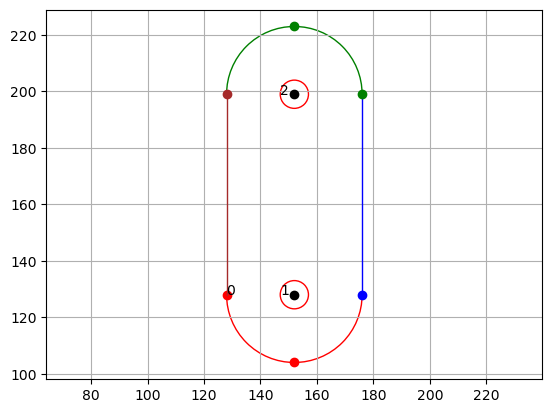

Profile after translating [-128. -128.]


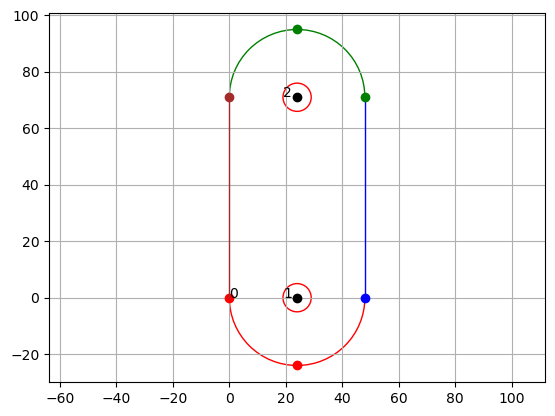

Profile after scaling by 0.012664473684210526


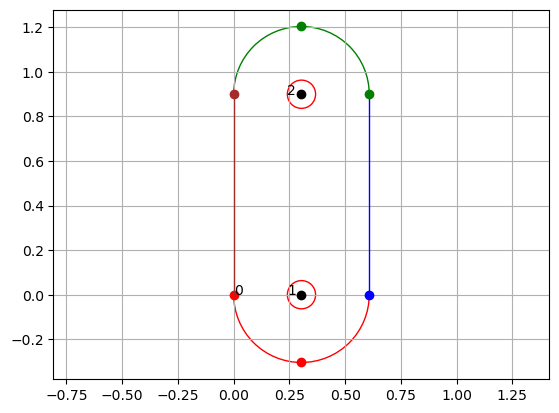

The recreated CAD-models are all still normalized within a 1x1x1 cube


In [102]:
extrusion = cad_seq.seq[0]
print(extrusion)
profile = copy(extrusion.profile)
denormalize_profile(profile, extrusion.sketch_size)
print("The recreated CAD-models are all still normalized within a 1x1x1 cube")

In [103]:
print(cad_seq)

(0)Sketch-Extrude pair:
  -origin: [-0.2969  0.     -0.4531], normal: [-0. -1. -0.], x_axis: [ 1. -0.  0.], y_axis: [-0. -0.  1.]
  -sketch position: [-0.2969  0.     -0.4531], sketch size: 1.2031
  -operation:0, type:0, extent_one:0.09375, extent_two:0.0
  -Profile:Loop:
      -Arc: start([0. 0.]), end([0.60789474 0.        ]), mid([ 0.30394737 -0.30394737])
      -Line: start([0.60789474 0.        ]), end([0.60789474 0.89917763])
      -Arc: start([0.60789474 0.89917763]), end([0.         0.89917763]), mid([0.30394737 1.203125  ])
      -Line: start([0.         0.89917763]), end([0. 0.])
    -Loop:
      -Circle: center([0.30394737 0.        ]), radius(0.06332236842105263)
    -Loop:
      -Circle: center([0.30394737 0.89917763]), radius(0.06332236842105263)


# Final Questions

- Why is the x and normal axis changing when numericalizing a CoordSyst?
- 

In [43]:
with h5py.File("/Users/saidharb/Documents/LocalDocuments/Master-Thesis/Point-Cloud-Reconstruction/data/latent/pretrained/results/test_1000/00000093_vec.h5") as hf:
    print(hf.keys())
    lol = hf['out_vec'][:]
    lol2 = hf['gt_vec'][:]
print("author out_vec", lol)
print("author gt_vec", lol2)

<KeysViewHDF5 ['gt_vec', 'out_vec']>
author out_vec [[  4  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 134 123   5   0  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 211 107   5   0  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 220 128   5   0  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 128 128   5   1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  5  -1  -1  -1  -1  -1 128 128 128  99 209 128  59 143 128   0   0]
 [  4  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 223 128   5   1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 211 133   5   0  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 140 133   5   0  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 128 128   5   0  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  5  -1  -1  -1  -1  -1 128 128 128  99 187 128  58 143 128   1   0]
 [  4  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 133 122   5   1  -1

In [44]:
with h5py.File("/Users/saidharb/Documents/LocalDocuments/Master-Thesis/Point-Cloud-Reconstruction/data/cad_vec/0000/00000061.h5") as hf:
    print(hf.keys())
    lol3 = hf['vec'][:]

<KeysViewHDF5 ['vec']>


In [45]:
print(lol3)

[[  4  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  0 223 128  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  0 223 223  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  0 138 223  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 128 214  64   0  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  0 128 128  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  5  -1  -1  -1  -1  -1 128 128 128 128  32 128  96 133 128   0   0]
 [  3  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]]


In [46]:
with h5py.File("/Users/saidharb/Documents/LocalDocuments/Master-Thesis/Point-Cloud-Reconstruction/models/trained_models/fifth_official_run/results/rec_metrics/output/00000093_vec.h5") as hf:
    print(hf.keys())
    lol3 = hf['out_vec'][:]
    lol4 = hf['gt_vec'][:]

<KeysViewHDF5 ['gt_vec', 'out_vec']>


In [47]:
print(lol3)
print(lol4)

[[  4  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 142 105  39   0  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 177  85  94   1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 197 128  94   1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 210 161 128   1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 160 158  25   1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 148 158 128   0  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 139 151  44   0  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  1 128 128  47   1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  4  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  2 144 129  -1  -1   5  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  4  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  2 159 169  -1  -1  13  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  4  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1]
 [  2 

In [48]:
a = [1,2,3,4]
a.index(3)

2

In [49]:
arsch = [1,2,3]


In [50]:
arsch[np.newaxis]

TypeError: list indices must be integers or slices, not NoneType

In [ ]:
EOS_VEC = np.array([EOS_IDX, *([PAD_VAL] * N_ARGS)])

In [ ]:
EOS_VEC

In [ ]:
EOS_VEC[np.newaxis]

In [ ]:
s = 2.0
e = 3.0
tmp = np.array([s, e])

In [ ]:
tmp

In [ ]:
path = "/Users/saidharb/Documents/LocalDocuments/Master-Thesis/Point-Cloud-Reconstruction/data/pc_cad/0000/00000007.ply"

In [ ]:
with open(path, "rb") as file:
    for _ in range(10):  # Read the first 10 lines
        line = file.readline()
        print(line.decode(errors="ignore"))


In [ ]:
from plyfile import PlyData, PlyElement

In [ ]:
def read_ply(path, with_normal=False):
    with open(path, 'rb') as f:
        plydata = PlyData.read(f)
        x = np.array(plydata['vertex']['x'])
        y = np.array(plydata['vertex']['y'])
        z = np.array(plydata['vertex']['z'])
        vertex = np.stack([x, y, z], axis=1)
        if with_normal:
            nx = np.array(plydata['vertex']['nx'])
            ny = np.array(plydata['vertex']['ny'])
            nz = np.array(plydata['vertex']['nz'])
            normals = np.stack([nx, ny, nz], axis=1)
    if with_normal:
        return np.concatenate([vertex, normals], axis=1)
    else:
        return vertex

In [ ]:
a = read_ply(path, with_normal=False)

In [ ]:
print(a.shape)

In [ ]:

def read_ply(path):
    with open(path, 'rb') as f:
        plydata = PlyData.read(f)
        x = np.array(plydata['vertex']['x'])
        y = np.array(plydata['vertex']['y'])
        z = np.array(plydata['vertex']['z'])
        vertex = np.stack([x, y, z], axis=1)
    return vertex

In [ ]:
a = read_ply(path)

In [ ]:
a.shape